In [1]:
# # This mounts your Google Drive to the Colab VM.
# from google.colab import drive
# drive.mount('/content/drive')

# # TODO: Enter the foldername in your Drive where you have saved the unzipped
# # assignment folder, e.g. 'cs231n/assignments/assignment3/'
# FOLDERNAME = 'cs231n/assignments/assignment3/'
# assert FOLDERNAME is not None, "[!] Enter the foldername."

# # Now that we've mounted your Drive, this ensures that
# # the Python interpreter of the Colab VM can load
# # python files from within it.
# import sys
# sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# # This downloads the COCO dataset to your Drive
# # if it doesn't already exist.
# %cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
# # !bash get_datasets.sh
# !bash get_coco_dataset.sh
# %cd /content/drive/My\ Drive/$FOLDERNAME


# Image Captioning with Transformers
You have now implemented a vanilla RNN and for the task of image captioning. In this notebook you will implement key pieces of a transformer decoder to accomplish the same task.

**NOTE:** This notebook will be primarily written in PyTorch rather than NumPy, unlike the RNN notebook.

In [2]:
# Setup cell.
import time, os, json
import numpy as np
import matplotlib.pyplot as plt

from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.transformer_layers import *
from cs231n.captioning_solver_transformer import CaptioningSolverTransformer
from cs231n.classifiers.transformer import CaptioningTransformer
from cs231n.coco_utils import load_coco_data, sample_coco_minibatch, decode_captions
from cs231n.image_utils import image_from_url

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # Set default size of plots.
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

# COCO Dataset
As in the previous notebooks, we will use the COCO dataset for captioning.

In [3]:
# Load COCO data from disk into a dictionary.
data = load_coco_data(pca_features=True)

# Print out all the keys and values from the data dictionary.
for k, v in data.items():
    if type(v) == np.ndarray:
        print(k, type(v), v.shape, v.dtype)
    else:
        print(k, type(v), len(v))

base dir  /home/haod6/assignment3/cs231n/datasets/coco_captioning
train_captions <class 'numpy.ndarray'> (400135, 17) int32
train_image_idxs <class 'numpy.ndarray'> (400135,) int32
val_captions <class 'numpy.ndarray'> (195954, 17) int32
val_image_idxs <class 'numpy.ndarray'> (195954,) int32
train_features <class 'numpy.ndarray'> (82783, 512) float32
val_features <class 'numpy.ndarray'> (40504, 512) float32
idx_to_word <class 'list'> 1004
word_to_idx <class 'dict'> 1004
train_urls <class 'numpy.ndarray'> (82783,) <U63
val_urls <class 'numpy.ndarray'> (40504,) <U63


# Transformer
As you have seen, RNNs are incredibly powerful but often slow to train. Further, RNNs struggle to encode long-range dependencies (though LSTMs are one way of mitigating the issue). In 2017, Vaswani et al introduced the Transformer in their paper ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) to a) introduce parallelism and b) allow models to learn long-range dependencies. The paper not only led to famous models like BERT and GPT in the natural language processing community, but also an explosion of interest across fields, including vision. While here we introduce the model in the context of image captioning, the idea of attention itself is much more general.



# Transformer for Image Captioning
Now that you have implemented the previous layers, you can combine them to build a Transformer-based image captioning model. Open the file `cs231n/classifiers/transformer.py` and look at the `CaptioningTransformer` class.

Implement the `forward` function of the class. After doing so, run the following to check your forward pass using a small test case; you should see error on the order of `e-5` or less.

# Overfit Transformer Captioning Model on Small Data
Run the following to overfit the Transformer-based captioning model on the same small dataset as we used for the RNN previously.

base dir  /home/haod6/assignment3/cs231n/datasets/coco_captioning
(Iteration 1 / 200) loss: 5.043721
(Iteration 11 / 200) loss: 2.813908
(Iteration 21 / 200) loss: 2.013232
(Iteration 31 / 200) loss: 1.670509
(Iteration 41 / 200) loss: 1.331776
(Iteration 51 / 200) loss: 1.232898
(Iteration 61 / 200) loss: 0.841003
(Iteration 71 / 200) loss: 0.709792
(Iteration 81 / 200) loss: 0.522991
(Iteration 91 / 200) loss: 0.466398
(Iteration 101 / 200) loss: 0.405149
(Iteration 111 / 200) loss: 0.157981
(Iteration 121 / 200) loss: 0.142865
(Iteration 131 / 200) loss: 0.116014
(Iteration 141 / 200) loss: 0.090493
(Iteration 151 / 200) loss: 0.071394
(Iteration 161 / 200) loss: 0.052108
(Iteration 171 / 200) loss: 0.034582
(Iteration 181 / 200) loss: 0.031838
(Iteration 191 / 200) loss: 0.025231


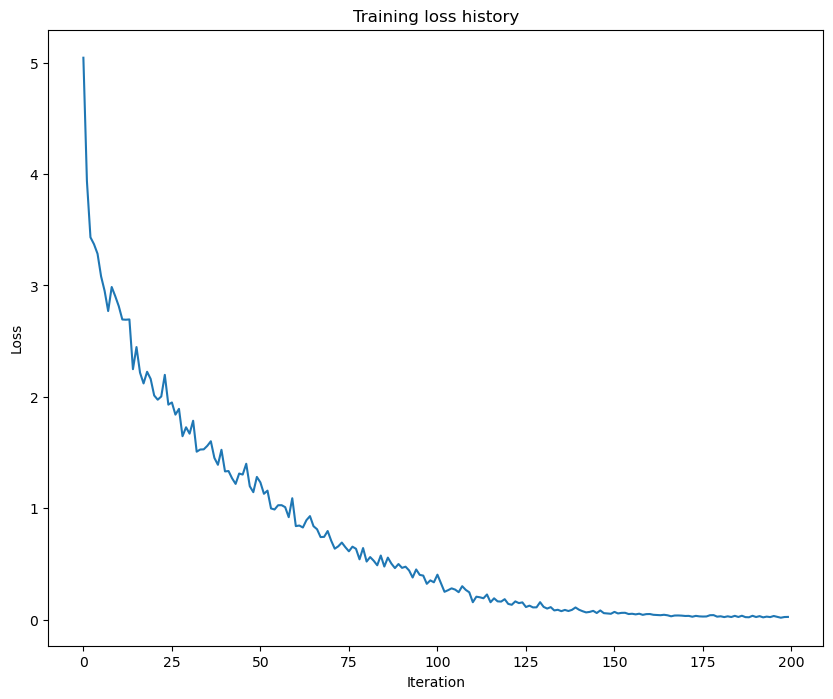

In [4]:
torch.manual_seed(231)
np.random.seed(231)

data = load_coco_data(max_train=50)

transformer = CaptioningTransformer(
          word_to_idx=data['word_to_idx'],
          input_dim=data['train_features'].shape[1],
          wordvec_dim=256,
          num_heads=2,
          num_layers=2,
          max_length=30
        )


transformer_solver = CaptioningSolverTransformer(transformer, data, idx_to_word=data['idx_to_word'],
           num_epochs=100,
           batch_size=25,
           learning_rate=0.001,
           verbose=True, print_every=10,
         )

transformer_solver.train()

# Plot the training losses.
plt.plot(transformer_solver.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training loss history')
plt.show()

Print final training loss. You should see a final loss of less than 0.05 .

In [5]:
print('Final loss: ', transformer_solver.loss_history[-1])

Final loss:  0.026092416


# Transformer Sampling at Test Time
The sampling code has been written for you. You can simply run the following to compare with the previous results with the RNN. As before the training results should be much better than the validation set results, given how little data we trained on.

URL Error:  Gone http://farm1.staticflickr.com/202/487987371_489a65d670_z.jpg


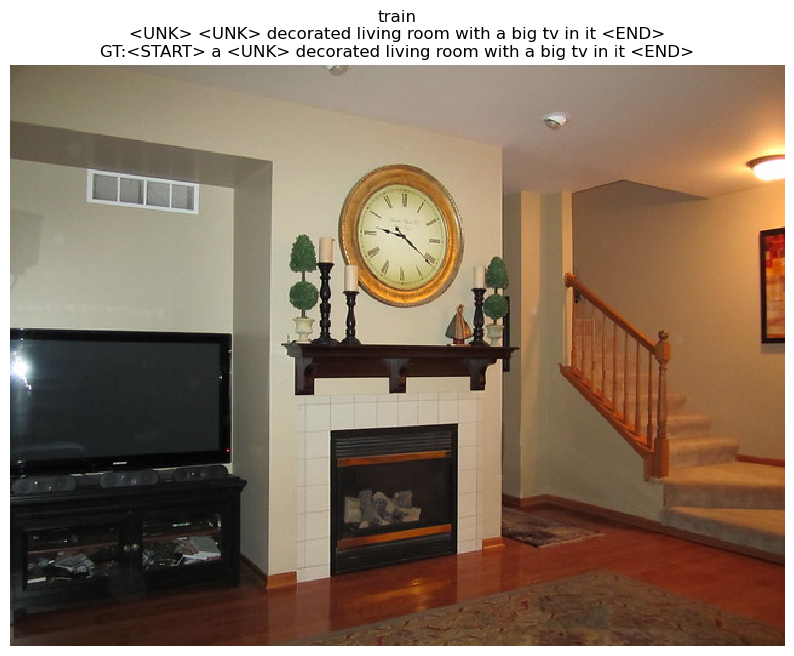

URL Error:  Not Found http://farm1.staticflickr.com/25/44101107_9491d72776_z.jpg


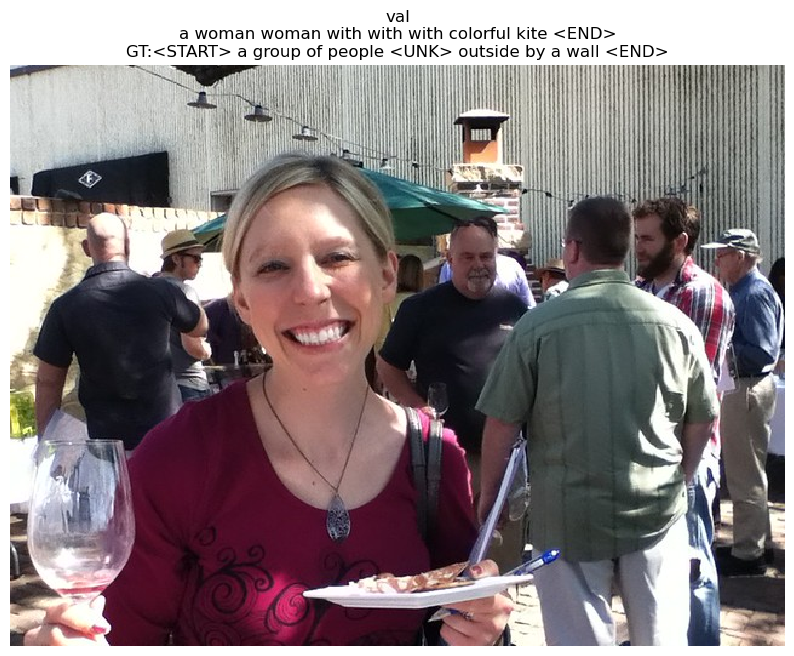

In [7]:
# If you get an error, the URL just no longer exists, so don't worry!
# You can re-sample as many times as you want.
for split in ['train', 'val']:
    minibatch = sample_coco_minibatch(data, split=split, batch_size=2)
    gt_captions, features, urls = minibatch
    gt_captions = decode_captions(gt_captions, data['idx_to_word'])

    sample_captions = transformer.sample(features, max_length=30)
    sample_captions = decode_captions(sample_captions, data['idx_to_word'])

    for gt_caption, sample_caption, url in zip(gt_captions, sample_captions, urls):
        img = image_from_url(url)
        # Skip missing URLs.
        if img is None: continue
        plt.imshow(img)
        plt.title('%s\n%s\nGT:%s' % (split, sample_caption, gt_caption))
        plt.axis('off')
        plt.show()

# Vision Transformer (ViT)

[Dosovitskiy et. al.](https://arxiv.org/abs/2010.11929) showed that applying a transformer model on a sequence of image patches (referred to as Vision Transformer) not only achieves impressive performance but also scales more effectively than convolutional neural networks when trained on large datasets. We will build a version of Vision Transformer using our existing implementation of transformer components and train it on the CIFAR-10 dataset.

Vision Transformer converts input image into a sequence of patches of fixed size and embed each patch into a latent vector. In `cs231n/transformer_layers.py`, complete the implementation of `PatchEmbedding` and test it below. You should see relative error less than 1e-4.


We will first verify our implementation by overfitting it on one training batch. Tune learning rate and weight decay accordingly.

In [6]:
from torchvision import transforms
from torchvision.datasets import CIFAR10
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

train_data = CIFAR10(root='data', train=True, transform=transforms.ToTensor(), download=True)
test_data = CIFAR10(root='data', train=False, transform=transforms.ToTensor(), download=True)

/home/haod6/.conda/envs/vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
from cs231n.classifiers.transformer import VisionTransformer
import torch

learning_rate = 6e-4  # Experiment with this
weight_decay = 0.0 # Experiment with this

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


batch = next(iter(DataLoader(train_data, batch_size=64, shuffle=False)))
model = VisionTransformer(dropout=0.0)
model = model.to(device)
loss_criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
model.train()

epochs = 100
for epoch in range(epochs):
    imgs, target = batch
    imgs, target = imgs.to(device), target.to(device)
    
    out = model(imgs)
    loss = loss_criterion(out, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    top1 = (out.argmax(-1) == target).float().mean().item()
    if epoch % 10 == 0:
      print(f"[{epoch}/{epochs}] Loss {loss.item():.6f}, Top-1 Accuracy: {top1:.3f}")


Using device: cuda
[0/100] Loss 2.300392, Top-1 Accuracy: 0.125
[10/100] Loss 2.143320, Top-1 Accuracy: 0.203
[20/100] Loss 1.951164, Top-1 Accuracy: 0.234
[30/100] Loss 1.815174, Top-1 Accuracy: 0.297
[40/100] Loss 1.602469, Top-1 Accuracy: 0.406
[50/100] Loss 1.377074, Top-1 Accuracy: 0.406
[60/100] Loss 0.966304, Top-1 Accuracy: 0.719
[70/100] Loss 0.700075, Top-1 Accuracy: 0.781
[80/100] Loss 0.361291, Top-1 Accuracy: 0.953
[90/100] Loss 0.174272, Top-1 Accuracy: 0.969


In [9]:
# You should get perfect 1.00 accuracy
print(f"Overfitting ViT on one batch. Top-1 accuracy: {top1}")

Overfitting ViT on one batch. Top-1 accuracy: 1.0


Now we will train it on the entire dataset.

In [10]:
from cs231n.classification_solver_vit import ClassificationSolverViT

############################################################################
# TODO: Train a Vision Transformer model that achieves over 0.45 test      #
# accuracy on CIFAR-10 after 2 epochs by adjusting the model architecture  #
# and/or training parameters as needed.                                    #
#                                                                          #
# Note: If you want to use a GPU runtime, go to `Runtime > Change runtime  #
# type` and set `Hardware accelerator` to `GPU`. This will reset Colab,    #
# so make sure to rerun the entire notebook from the beginning afterward.  #
############################################################################


learning_rate = 1e-3
weight_decay = 1e-4
batch_size = 64
model = VisionTransformer(
    patch_size=4,      
    embed_dim=128,   
    num_layers=6, 
    num_heads=4,  
    dim_feedforward=256, 
    dropout=0.1
)  # You may want to change the default params.




################################################################################
#                                 END OF YOUR CODE                             #
################################################################################

solver = ClassificationSolverViT(
    train_data=train_data,
    test_data=test_data,
    model=model,
    num_epochs = 2,  # Don't change this
    learning_rate = learning_rate,
    weight_decay = weight_decay,
    batch_size = batch_size,
)

solver.train('cuda' if torch.cuda.is_available() else 'cpu')



Test Epoch: [1/2] Loss: 1.4162 ACC@1: 0.483%: 100%|██████████| 157/157 [00:00<00:00, 248.05it/s]


In [11]:
print(f"Accuracy on test set: {solver.results['best_test_acc']}")

Accuracy on test set: 0.4834


In [12]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total: {total_params:,}")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable: {trainable_params:,}")

Total: 802,442
Trainable: 802,442


In [13]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class SignLanguageMNIST(Dataset):
    def __init__(self, csv_file, transform=None):
        data = pd.read_csv(csv_file)
        self.labels = np.array(data.iloc[:, 0])
        self.images = np.array(data.iloc[:, 1:]).reshape(-1, 28, 28).astype(np.uint8)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        from PIL import Image
        image = Image.fromarray(image)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(15),     
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)), # 随机缩放裁剪
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # 亮度对比度
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 测试集保持简单，不要加随机增强
transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = SignLanguageMNIST('./data/sign/sign_mnist_train.csv', transform=transform_train)
test_data = SignLanguageMNIST('./data/sign/sign_mnist_test.csv', transform=transform_test)

In [14]:
from cs231n.classification_solver_vit import ClassificationSolverViT

learning_rate = 5e-4 # 略微调低学习率，ViT 对高 LR 较敏感
weight_decay = 1e-5
batch_size = 64

model = VisionTransformer(
    img_size=32,       # 匹配 transform 中的 Resize
    patch_size=4,      # 32/4 = 8x8 patches
    in_channels=1,        # ！！！注意：如果是灰度图，这里改为 1
    num_classes=25,    # ！！！注意：Sign Language MNIST 标签范围到 24
    embed_dim=256,   
    num_layers=3,    
    num_heads=8,  
    dim_feedforward=512,
    dropout=0.1
)

solver = ClassificationSolverViT(
    train_data=train_data,
    test_data=test_data,
    model=model,
    num_epochs = 10,
    learning_rate = learning_rate,
    weight_decay = weight_decay,
    batch_size = batch_size,
)

solver.train('cuda' if torch.cuda.is_available() else 'cpu')

Test Epoch: [9/10] Loss: 0.1072 ACC@1: 0.969%: 100%|██████████| 113/113 [00:00<00:00, 199.64it/s]


In [15]:
print(f"Accuracy on test set: {solver.results['best_test_acc']}")

Accuracy on test set: 0.968627997769102


In [16]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total: {total_params:,}")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable: {trainable_params:,}")

Total: 1,592,089
Trainable: 1,592,089
